In [1]:
# ====== Import the required modules
import pandas as pd
import yfinance as yf
from prophet import Prophet
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import logging


In [2]:
# ====== Other settings for logging and pandas
logging.getLogger('prophet').setLevel(logging.WARNING)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
# ====== Define the ticker and date range
ticker = "NAIL"
end_date = datetime.now() # Current date and time
start_date = end_date - timedelta(days=5*365) # Approx 5 years back (ignores leap years)
end_date = end_date.strftime('%Y-%m-%d') 
start_date = start_date.strftime('%Y-%m-%d') 

print(end_date)
print(start_date)
# Fetch data using yfinance
stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
display(stock_data.sample(5))

2025-03-19
2020-03-20
YF.download() has changed argument auto_adjust default to True


Price,Close,High,Low,Open,Volume
Ticker,NAIL,NAIL,NAIL,NAIL,NAIL
Date,,,,,
2024-07-25,132.496765,140.249612,125.569104,127.687417,687900
2020-04-01,7.661704,8.985900,7.433736,8.702427,867100
2022-08-30,29.269098,31.142399,28.922190,30.696374,435300
2020-12-07,46.495541,46.634303,42.729115,43.621161,837300
2022-03-09,54.335655,56.317985,52.502002,52.502002,409700


In [4]:
# ====== Extract the 'Price' level from the MultiIndex and use it as column names
if isinstance(stock_data.columns, pd.MultiIndex):
    # Get the 'Price' level values (first element of each tuple)
    new_columns = [col[0] for col in stock_data.columns]
    stock_data.columns = new_columns  # Flatten to single-level columns

# Verify the updated column names
print("\nUpdated column structure:")
print(stock_data.columns)
display(stock_data.sample(5))


Updated column structure:
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


,Close,High,Low,Open,Volume
Date,,,,,
2021-02-11,70.224014,71.601733,68.241685,69.292325,459700
2023-11-08,58.595169,60.327636,57.499934,58.754476,316500
2022-09-21,24.115038,26.533480,24.035745,25.463023,526100
2022-02-18,60.748497,62.393831,58.558024,60.540353,318100
2022-08-18,38.506744,38.774359,37.654346,38.665331,231800


In [5]:
# ====== Prepare data for Prophet using 'Close'
df = stock_data[['Close']].reset_index()
df.columns = ['ds', 'y']  # Rename to Prophet-compatible columns

# Handle missing values and ensure datetime format
df = df.dropna()
df['ds'] = pd.to_datetime(df['ds'])

# Display the cleaned DataFrame sample
print("\nCleaned DataFrame (first 5 rows):")
display(df.head())


Cleaned DataFrame (first 5 rows):


,ds,y
0,2020-03-20,7.547097
1,2020-03-23,6.704239
2,2020-03-24,9.624211
3,2020-03-25,12.260709
4,2020-03-26,13.727633


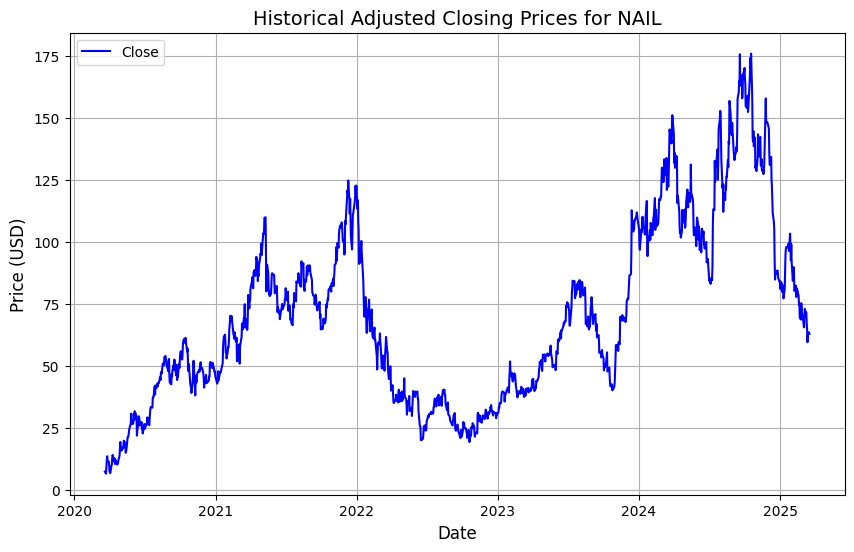


Basic Statistics of Adjusted Close Prices:
count    1255.000000
mean       69.777452
std        36.350683
min         6.704239
25%        40.409792
50%        64.760857
75%        92.416042
max       175.817688
Name: y, dtype: float64


In [6]:
# Plot historical data
plt.figure(figsize=(10, 6))
plt.plot(df['ds'], df['y'], label='Close', color='blue')
plt.title(f'Historical Adjusted Closing Prices for {ticker}', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Basic statistics
print("\nBasic Statistics of Adjusted Close Prices:")
print(df['y'].describe())

In [7]:
# ======= Make forecast dataframe
horizon = 14
latest_dates = datetime.now()  - timedelta(days=horizon*5)
current_df = df[df['ds'] >= latest_dates]
display(current_df.head(3))
display(current_df.tail(3))

,ds,y
1209,2025-01-10,77.309998
1210,2025-01-13,81.019997
1211,2025-01-14,88.160004


,ds,y
1252,2025-03-14,62.639999
1253,2025-03-17,63.669998
1254,2025-03-18,63.000000


In [8]:
# ====== Initialize and fit the Prophet model
model = Prophet(
    daily_seasonality=True,
    yearly_seasonality=False,  # Disable yearly seasonality (short time frame)
    weekly_seasonality=True,
    changepoint_prior_scale=0.5,  # Increase flexibility for trend changes
    seasonality_mode='multiplicative'  # Better for stock price volatility
)
model.fit(current_df)

11:48:21 - cmdstanpy - INFO - Chain [1] start processing
11:48:22 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
# ====== Create future dataframe for the next 30 days
future = model.make_future_dataframe(periods=horizon)
print(f"\nFuture dates for forecast (last {horizon} rows):")
display(future.tail(horizon))


Future dates for forecast (last 14 rows):


,ds
46,2025-03-19
47,2025-03-20
48,2025-03-21
49,2025-03-22
50,2025-03-23
51,2025-03-24
52,2025-03-25
53,2025-03-26
54,2025-03-27
55,2025-03-28


In [10]:
# ====== Generate forecast
forecast = model.predict(future)
display(forecast.tail(horizon))

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,daily,daily_lower,daily_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,weekly,weekly_lower,weekly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
46,2025-03-19,1.452047,55.690761,61.422251,1.407125,1.488485,38.71324,38.71324,38.71324,39.381121,39.381121,39.381121,0.667881,0.667881,0.667881,0.0,0.0,0.0,58.635272
47,2025-03-20,1.434112,52.949117,66.812616,1.287389,1.589608,38.71324,38.71324,38.71324,40.672890,40.672890,40.672890,1.959650,1.959650,1.959650,0.0,0.0,0.0,59.763612
48,2025-03-21,1.416178,46.042758,72.263104,1.126109,1.746414,38.71324,38.71324,38.71324,40.281367,40.281367,40.281367,1.568127,1.568127,1.568127,0.0,0.0,0.0,58.461778
49,2025-03-22,1.398244,31.079198,67.765784,0.918320,1.959893,38.71324,38.71324,38.71324,33.874084,33.874084,33.874084,-4.839156,-4.839156,-4.839156,0.0,0.0,0.0,48.762484
50,2025-03-23,1.380310,22.959108,76.764217,0.653193,2.206829,38.71324,38.71324,38.71324,33.874080,33.874080,33.874080,-4.839160,-4.839160,-4.839160,0.0,0.0,0.0,48.137041
51,2025-03-24,1.362376,16.320000,106.251226,0.365003,2.460531,38.71324,38.71324,38.71324,42.250782,42.250782,42.250782,3.537542,3.537542,3.537542,0.0,0.0,0.0,58.923819
52,2025-03-25,1.344442,3.695685,112.121295,0.084201,2.718855,38.71324,38.71324,38.71324,40.658356,40.658356,40.658356,1.945116,1.945116,1.945116,0.0,0.0,0.0,56.007229
53,2025-03-26,1.326507,-8.679005,121.588576,-0.203617,2.990436,38.71324,38.71324,38.71324,39.381121,39.381121,39.381121,0.667881,0.667881,0.667881,0.0,0.0,0.0,53.565858
54,2025-03-27,1.308573,-22.376180,134.824820,-0.524141,3.250577,38.71324,38.71324,38.71324,40.672890,40.672890,40.672890,1.959650,1.959650,1.959650,0.0,0.0,0.0,54.532031
55,2025-03-28,1.290639,-36.894866,145.812956,-0.895767,3.531879,38.71324,38.71324,38.71324,40.281367,40.281367,40.281367,1.568127,1.568127,1.568127,0.0,0.0,0.0,53.279348


In [11]:
# ====== Display the last rows for the forecast
display(forecast[['ds', 'trend', 'yhat', 'yhat_lower', 'yhat_upper']].tail(horizon))

,ds,trend,yhat,yhat_lower,yhat_upper
46,2025-03-19,1.452047,58.635272,55.690761,61.422251
47,2025-03-20,1.434112,59.763612,52.949117,66.812616
48,2025-03-21,1.416178,58.461778,46.042758,72.263104
49,2025-03-22,1.398244,48.762484,31.079198,67.765784
50,2025-03-23,1.380310,48.137041,22.959108,76.764217
51,2025-03-24,1.362376,58.923819,16.320000,106.251226
52,2025-03-25,1.344442,56.007229,3.695685,112.121295
53,2025-03-26,1.326507,53.565858,-8.679005,121.588576
54,2025-03-27,1.308573,54.532031,-22.376180,134.824820
55,2025-03-28,1.290639,53.279348,-36.894866,145.812956


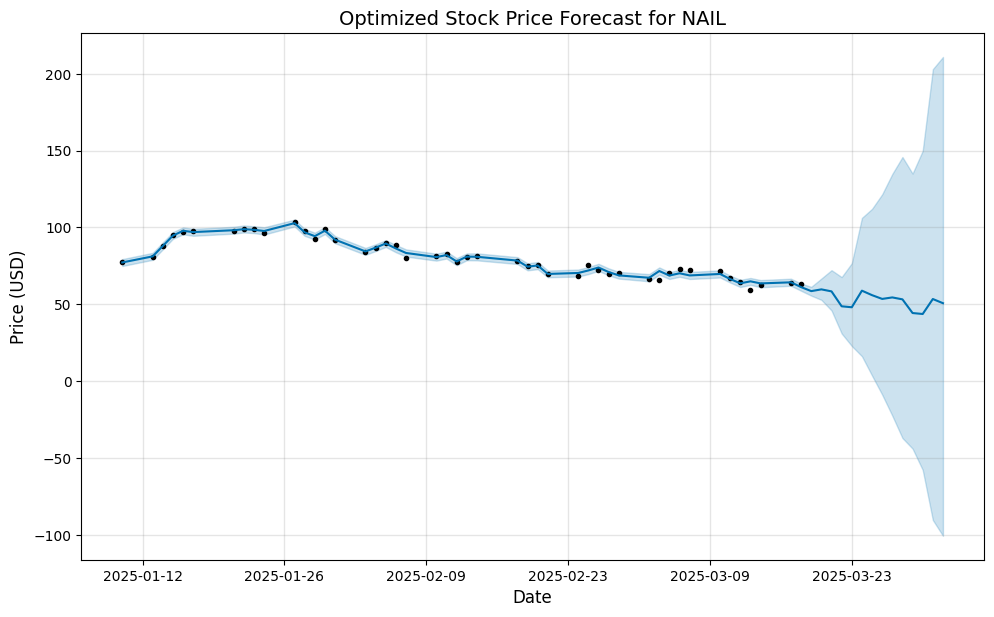

In [12]:
# ====== Plot forecast
fig1 = model.plot(forecast[['ds', 'trend', 'yhat', 'yhat_lower', 'yhat_upper']])
plt.title(f'Optimized Stock Price Forecast for {ticker}', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True)
plt.show()

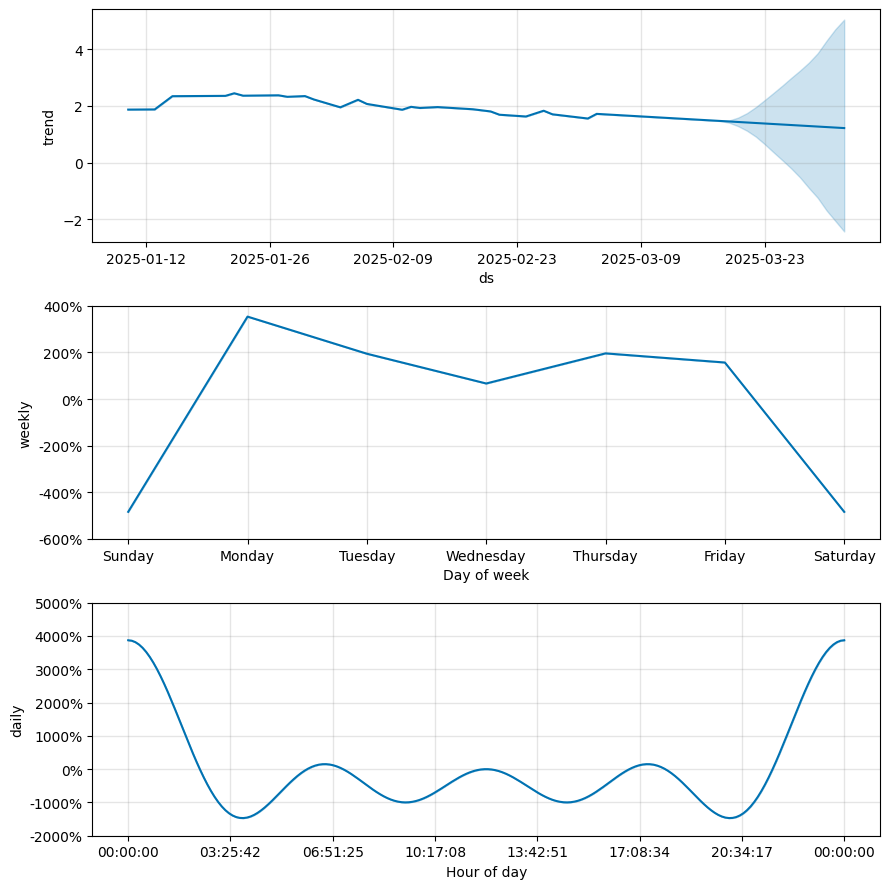

In [13]:
# ====== Plot components
fig2 = model.plot_components(forecast)
plt.show()